# 📊 Notebook 1: Visión General del Proyecto y Análisis Exploratorio de Datos (EDA)

> Este notebook realiza el **análisis exploratorio completo** del dataset Avazu (~40M registros de impresiones publicitarias móviles) para entender la estructura, distribución y patrones de clics antes del modelado.

### 📋 Contenido:
1. **Carga del dataset** desde `data/raw/train.gz`
2. **Inspección básica** — `.shape`, `.dtypes`, `.head()`, `.describe()`, `.info()`
3. **Valores faltantes** — tabla y gráfico de missings
4. **Distribución del target** (`click`) con balance de clases
5. **Cardinalidad** de todas las variables categóricas
6. **Feature Engineering temporal** — `day`, `hour_of_day`, `franja_horaria`
7. **Visualizaciones completas** — histogramas, frecuencias, CTR por segmentos, correlaciones
8. **Dashboard resumen** con métricas clave del dataset

### ⚙️ Requisitos:
- Dataset en `data/raw/train.gz` (comprimido, se lee directamente)
- Entorno: `deep_env` con las dependencias del proyecto

---

---

## ⚙️ 0.1 Configuración del Entorno e Importaciones

> **Cargamos todas las librerías necesarias y aplicamos el estilo visual oscuro profesional que se mantendrá consistente en todos los notebooks del proyecto.**

---

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError("No se encontró la raíz del proyecto con el directorio src.")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from ctr_mlp.config import load_project_settings, apply_dark_style, COLORS, PALETTE_CATEGORICAL
from ctr_mlp.data_io import estimate_target_distribution, read_dataframe_preview
from ctr_mlp.eda import (
    build_schema_report,
    categorical_cardinality,
    plot_click_rate_by_hour,
    plot_correlation_heatmap,
    plot_numeric_histograms,
    plot_target_distribution,
    plot_top_categories,
    plot_missing_values,
    plot_cardinality_chart,
    plot_ctr_by_category,
    plot_top_with_ctr,
    plot_records_by_day,
    plot_dashboard_summary,
    save_figure,
)
from ctr_mlp.feature_engineering import add_time_features_pandas

# Aplicar estilo visual oscuro profesional
apply_dark_style()

settings = load_project_settings()
paths = settings["paths"]
general = settings["general"]
feature_cfg = settings["features"]

TRAIN_PATH = paths["train_csv"]
FIGURES_DIR = paths["figures_dir"]
TARGET_COL = general["target_col"]

assert Path(TRAIN_PATH).exists(), f"Dataset no encontrado: {TRAIN_PATH}"
print(f"Dataset: {TRAIN_PATH}")
print(f"Figuras se guardarán en: {FIGURES_DIR}")

Dataset: C:\Users\juana\Deep_learning1-main\data\raw\train.gz
Figuras se guardarán en: C:\Users\juana\Deep_learning1-main\reports\figures


---

## 📥 1.1 Carga del Dataset

> **Cargamos una vista previa del dataset comprimido (`train.gz`) directamente sin descomprimirlo. Usamos 150,000 filas para el EDA, suficientes para análisis representativo sin saturar la memoria.**

---

In [2]:
preview_df = read_dataframe_preview(
    TRAIN_PATH,
    nrows=general["preview_rows"],
    compression="gzip",
)
print(f"Shape del preview: {preview_df.shape}")
print(f"Columnas: {list(preview_df.columns)}")

Shape del preview: (150000, 24)
Columnas: ['id', 'click', 'hour', 'C1', 'banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']


---

## 🔍 1.2 Inspección Básica del Dataset

> **Examinamos la estructura fundamental del dataset: tipos de datos, primeras filas, estadísticas descriptivas e información general. Esto nos permite identificar rápidamente qué variables son categóricas, cuáles numéricas y si hay anomalías evidentes.**

---

In [3]:
# .head() — Primeras filas del dataset
print("═" * 60)
print("PRIMERAS 5 FILAS (.head())")
print("═" * 60)
display(preview_df.head())

# .shape
print(f"\nShape: {preview_df.shape} ({preview_df.shape[0]:,} filas × {preview_df.shape[1]} columnas)")

# .dtypes
print("\n" + "═" * 60)
print("TIPOS DE DATOS (.dtypes)")
print("═" * 60)
display(preview_df.dtypes.to_frame(name="dtype"))

# .describe()
print("\n" + "═" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS (.describe())")
print("═" * 60)
display(preview_df.describe(include="all").T)

# .info()
print("\n" + "═" * 60)
print("INFORMACIÓN GENERAL (.info())")
print("═" * 60)
preview_df.info()

════════════════════════════════════════════════════════════
PRIMERAS 5 FILAS (.head())
════════════════════════════════════════════════════════════


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1000009418151094273,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,2,15706,320,50,1722,0,35,-1,79
1,10000169349117863715,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
2,10000371904215119486,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
3,10000640724480838376,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15706,320,50,1722,0,35,100084,79
4,10000679056417042096,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,...,1,0,18993,320,50,2161,0,35,-1,157



Shape: (150000, 24) (150,000 filas × 24 columnas)

════════════════════════════════════════════════════════════
TIPOS DE DATOS (.dtypes)
════════════════════════════════════════════════════════════


,dtype
id,string
click,int8
hour,string
C1,int16
banner_pos,int8
site_id,string
site_domain,string
site_category,string
app_id,string
app_domain,string



════════════════════════════════════════════════════════════
ESTADÍSTICAS DESCRIPTIVAS (.describe())
════════════════════════════════════════════════════════════


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,150000,150000,1000009418151094273,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
click,150000.0,NaN,NaN,NaN,0.174113,0.379208,0.0,0.0,0.0,0.0,1.0
hour,150000,2,14102100,119006,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C1,150000.0,NaN,NaN,NaN,1005.028827,1.06237,1001.0,1005.0,1005.0,1005.0,1010.0
banner_pos,150000.0,NaN,NaN,NaN,0.202887,0.40606,0.0,0.0,0.0,0.0,7.0
site_id,150000,1093,1fbe01fe,50828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site_domain,150000,979,f3845767,50828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site_category,150000,20,28905ebd,54739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_id,150000,871,ecad2386,115898,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_domain,150000,65,7801e8d9,122547,NaN,NaN,NaN,NaN,NaN,NaN,NaN



════════════════════════════════════════════════════════════
INFORMACIÓN GENERAL (.info())
════════════════════════════════════════════════════════════
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                150000 non-null  string
 1   click             150000 non-null  int8  
 2   hour              150000 non-null  string
 3   C1                150000 non-null  int16 
 4   banner_pos        150000 non-null  int8  
 5   site_id           150000 non-null  string
 6   site_domain       150000 non-null  string
 7   site_category     150000 non-null  string
 8   app_id            150000 non-null  string
 9   app_domain        150000 non-null  string
 10  app_category      150000 non-null  string
 11  device_id         150000 non-null  string
 12  device_ip         150000 non-null  string
 13  device_model      150000 non-null  st

---

## ❓ 1.3 Verificación de Valores Faltantes

> **Analizamos la completitud de cada columna. En datasets de publicidad como Avazu, es común que las columnas estén completas ya que provienen de logs de servidores, pero es importante verificarlo antes de proceder al modelado.**

---

Resumen de valores faltantes por columna:


,missing_values,missing_rate
id,0,0.0
device_ip,0,0.0
device_id,0,0.0
device_model,0,0.0
site_id,0,0.0
site_domain,0,0.0
app_id,0,0.0
C14,0,0.0
C20,0,0.0
C17,0,0.0



Total de valores faltantes en el dataset: 0


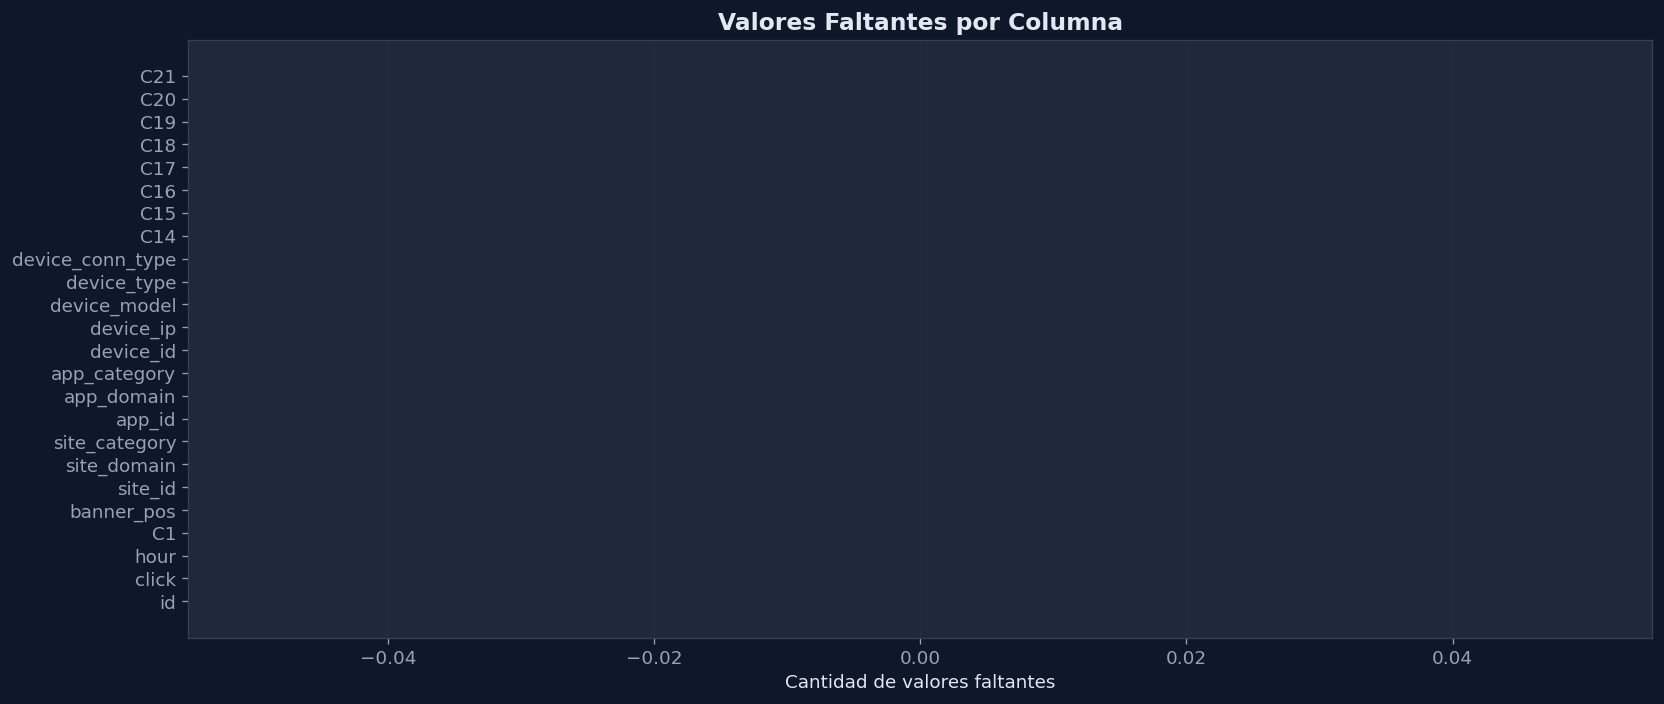

In [4]:
# Tabla de valores faltantes
schema_report = build_schema_report(preview_df)
missing_summary = schema_report[["missing_values", "missing_rate"]]
print("Resumen de valores faltantes por columna:")
display(missing_summary)

total_missing = int(preview_df.isna().sum().sum())
print(f"\nTotal de valores faltantes en el dataset: {total_missing:,}")

# Gráfico de valores faltantes
fig_missing = plot_missing_values(preview_df, save_path=FIGURES_DIR / "01_missing_values.png")
plt.show()

---

## 🎯 1.4 Distribución de la Variable Target (`click`)

> **Analizamos el balance de clases para entender el desbalance inherente del dataset. Un CTR típico en publicidad móvil es del 2-5%, lo que implica un fuerte desbalance que debemos considerar en el modelado. Calculamos la distribución global usando lectura por chunks sobre todo el dataset.**

---

Calculando distribución global del target (lectura por chunks)...

Total de registros en el dataset completo: 40,428,967
CTR global: 16.98%


,count,share,percentage
click,,,
0,33563901,0.8302,83.02
1,6865066,0.1698,16.98


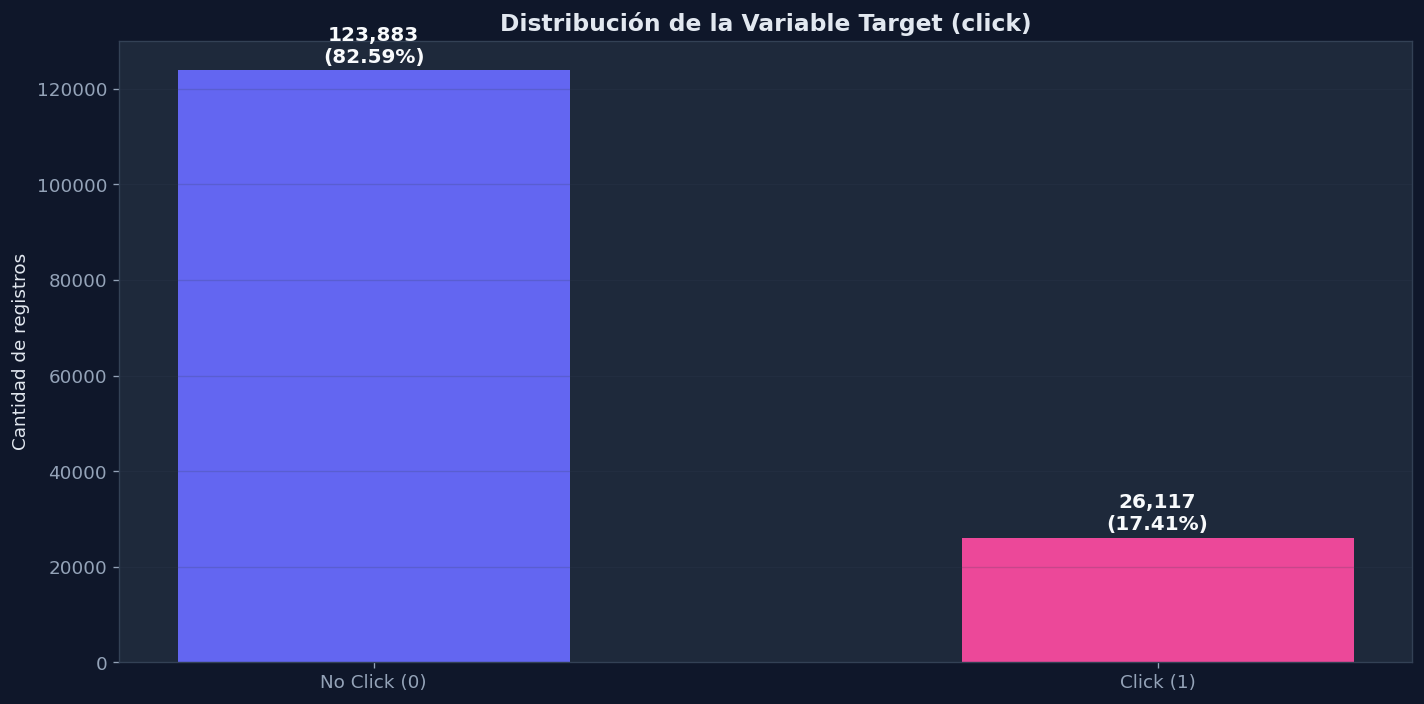

In [5]:
# Distribución global (leyendo TODO el dataset por chunks)
print("Calculando distribución global del target (lectura por chunks)...")
full_target_counts = estimate_target_distribution(
    TRAIN_PATH,
    target_col=TARGET_COL,
    chunksize=general["chunksize"],
    compression="gzip",
)
target_stats = pd.DataFrame({
    "count": full_target_counts,
    "share": (full_target_counts / full_target_counts.sum()).round(4),
    "percentage": ((full_target_counts / full_target_counts.sum()) * 100).round(2),
})
print(f"\nTotal de registros en el dataset completo: {full_target_counts.sum():,}")
print(f"CTR global: {target_stats.loc[1, 'percentage']:.2f}%")
display(target_stats)

# Gráfico de distribución del target
fig_target = plot_target_distribution(
    preview_df, target_col=TARGET_COL,
    save_path=FIGURES_DIR / "01_target_distribution.png"
)
plt.show()

---

## 🗂️ 1.5 Cardinalidad de Variables Categóricas

> **Analizamos cuántos valores únicos tiene cada variable categórica. Las variables con muy alta cardinalidad (como `device_id`, `device_ip`, `site_id`) requieren tratamiento especial (Target Encoding) mientras que las de baja cardinalidad pueden usar OneHot Encoding sin problemas.**

---

Total de variables categóricas analizadas: 23


,cardinality
id,150000
device_ip,59636
device_id,11191
device_model,2862
site_id,1093
site_domain,979
app_id,871
C14,463
C20,146
C17,143


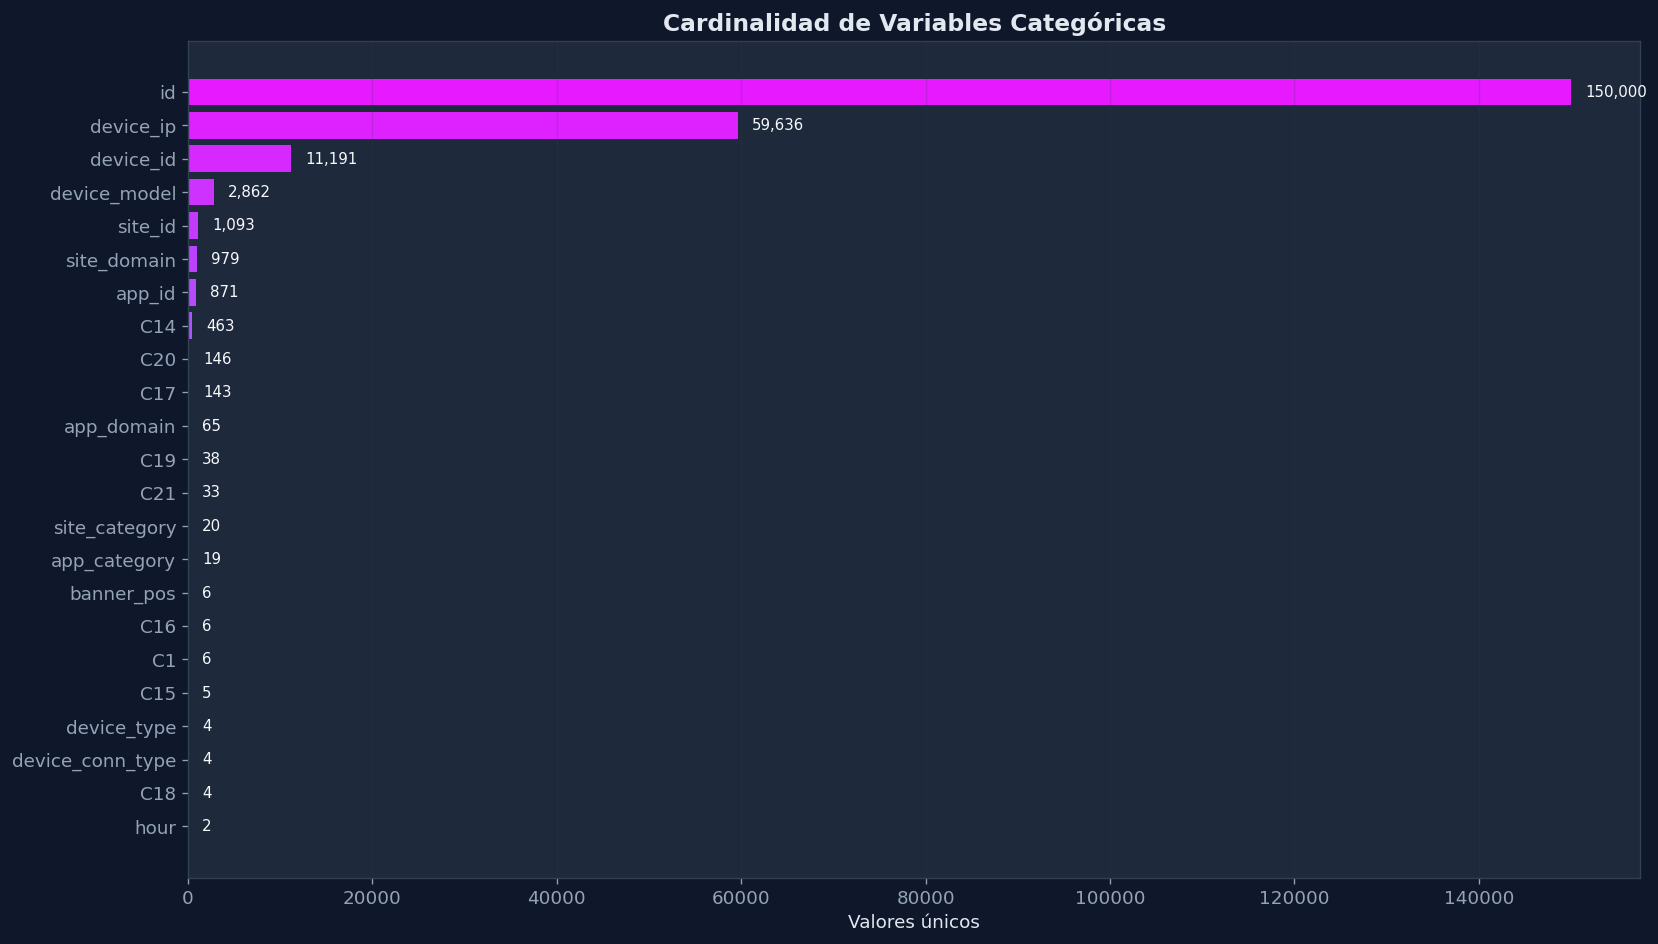

In [6]:
# Identificar TODAS las variables categóricas
all_categorical = [
    col for col in preview_df.columns
    if preview_df[col].dtype in ["object", "string", "category"]
    or col in ["C1", "banner_pos", "device_type", "device_conn_type",
               "C14", "C15", "C16", "C17", "C18", "C19", "C20", "C21"]
]
# Eliminar duplicados manteniendo orden
all_categorical = list(dict.fromkeys(all_categorical))

cardinality_report = categorical_cardinality(preview_df, all_categorical)
print(f"Total de variables categóricas analizadas: {len(all_categorical)}")
display(cardinality_report)

# Gráfico de cardinalidad (barras horizontales ordenadas)
fig_card = plot_cardinality_chart(
    cardinality_report,
    save_path=FIGURES_DIR / "01_cardinality_chart.png"
)
plt.show()

---

## ⏰ 1.6 Feature Engineering Temporal

> **Transformamos la columna `hour` (formato YYMMDDHH) en nuevas features interpretables: `event_day` (día), `event_hour` (hora del día) y `franja_horaria` (madrugada/mañana/tarde/noche). Estas variables capturan patrones temporales de comportamiento del usuario.**

---

In [7]:
# Aplicar ingeniería de features temporales
preview_df = add_time_features_pandas(preview_df, hour_col=general["hour_col"])

# Mostrar las nuevas columnas creadas
time_cols = ["hour", "event_day", "event_hour", "day_of_week",
             "is_weekend", "is_business_hour", "time_bucket", "franja_horaria"]
print("Nuevas features temporales creadas:")
display(preview_df[time_cols].head(10))

print(f"\nValores únicos de franja_horaria: {preview_df['franja_horaria'].unique().tolist()}")
print(f"Distribución de franjas horarias:")
display(preview_df["franja_horaria"].value_counts())

Nuevas features temporales creadas:


,hour,event_day,event_hour,day_of_week,is_weekend,is_business_hour,time_bucket,franja_horaria
0,14102100,21,0,1,0,0,madrugada,Madrugada (00-05h)
1,14102100,21,0,1,0,0,madrugada,Madrugada (00-05h)
2,14102100,21,0,1,0,0,madrugada,Madrugada (00-05h)
3,14102100,21,0,1,0,0,madrugada,Madrugada (00-05h)
4,14102100,21,0,1,0,0,madrugada,Madrugada (00-05h)
5,14102100,21,0,1,0,0,madrugada,Madrugada (00-05h)
6,14102100,21,0,1,0,0,madrugada,Madrugada (00-05h)
7,14102100,21,0,1,0,0,madrugada,Madrugada (00-05h)
8,14102100,21,0,1,0,0,madrugada,Madrugada (00-05h)
9,14102100,21,0,1,0,0,madrugada,Madrugada (00-05h)



Valores únicos de franja_horaria: ['Madrugada (00-05h)']
Distribución de franjas horarias:


franja_horaria
Madrugada (00-05h)    150000
Name: count, dtype: int64[pyarrow]

---

## 📊 2.1 Histogramas de Variables Numéricas Derivadas

> **Visualizamos la distribución de las variables numéricas clave: `event_hour`, `event_day`, `C1`, `banner_pos`, `device_type` y `device_conn_type`. Esto nos permite identificar patrones de concentración y posibles outliers.**

---

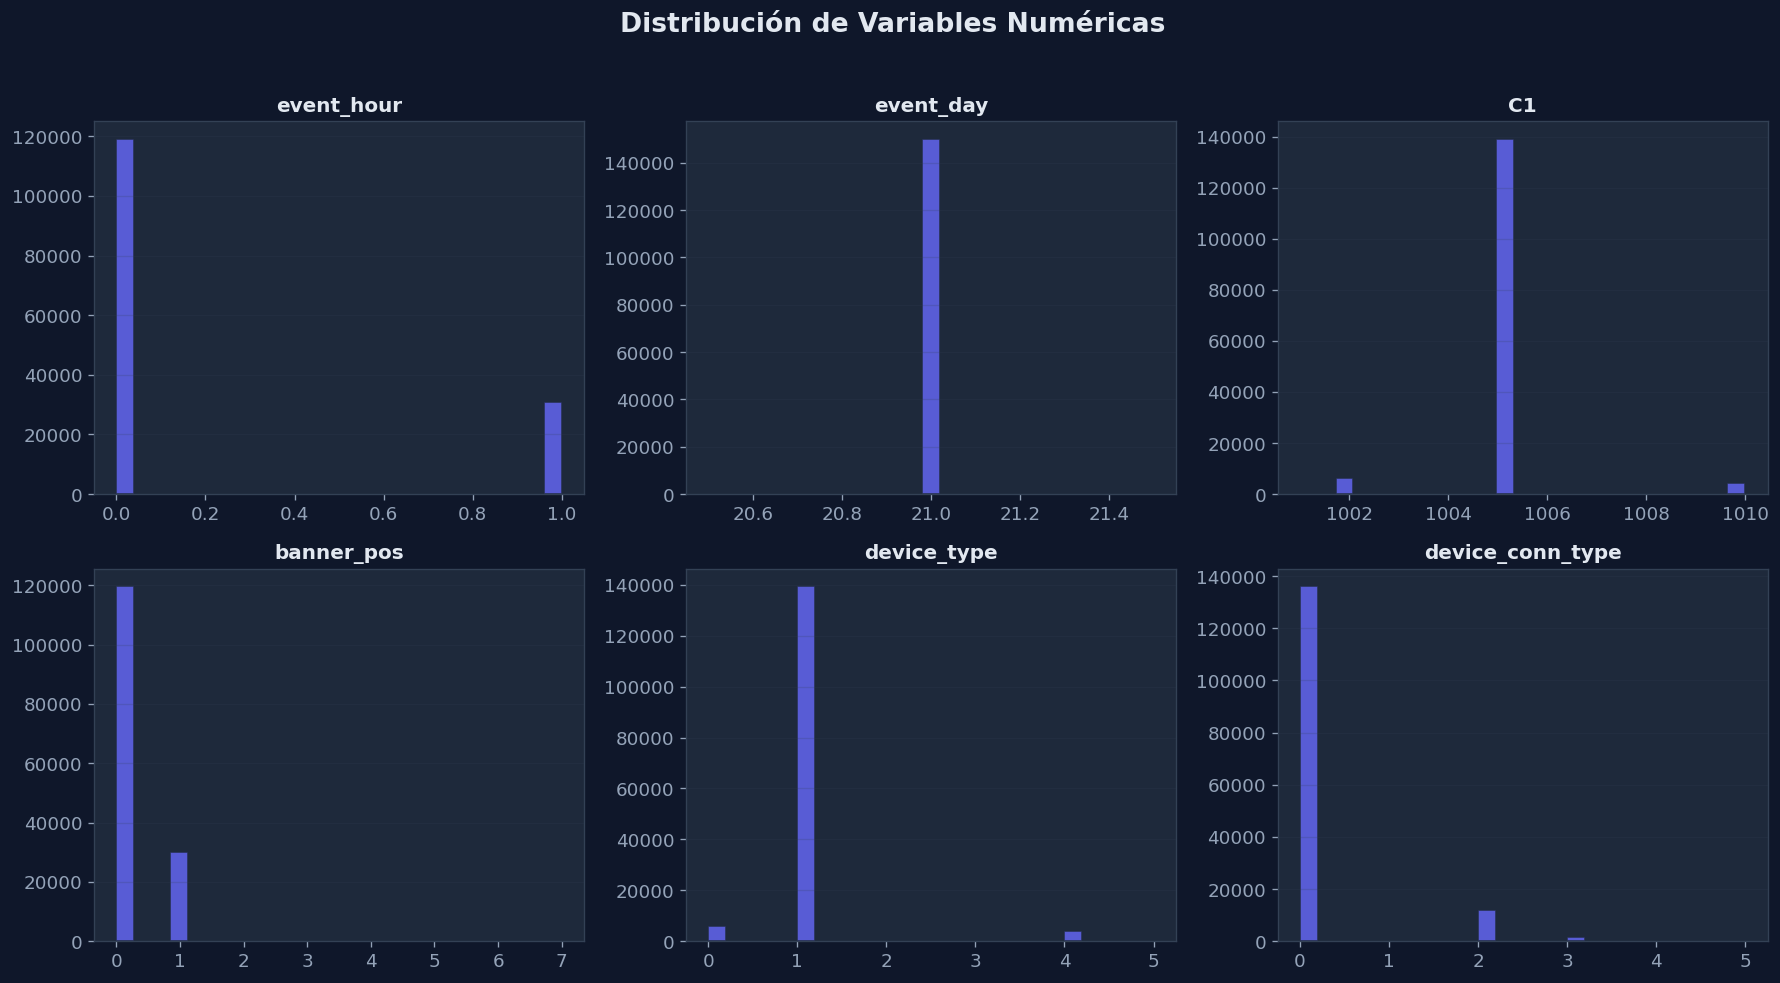

In [8]:
hist_cols = ["event_hour", "event_day", "C1", "banner_pos", "device_type", "device_conn_type"]
fig_hist = plot_numeric_histograms(
    preview_df, hist_cols, bins=25,
    save_path=FIGURES_DIR / "01_numeric_histograms.png"
)
plt.show()

---

## 📈 2.2 Frecuencia de las Principales Variables Categóricas

> **Examinamos los top 10-15 valores más frecuentes de las variables categóricas de alta cardinalidad: `site_id`, `site_domain`, `app_id`, `app_domain` y `device_model`. Esto revela qué sitios, apps y dispositivos dominan el dataset.**

---

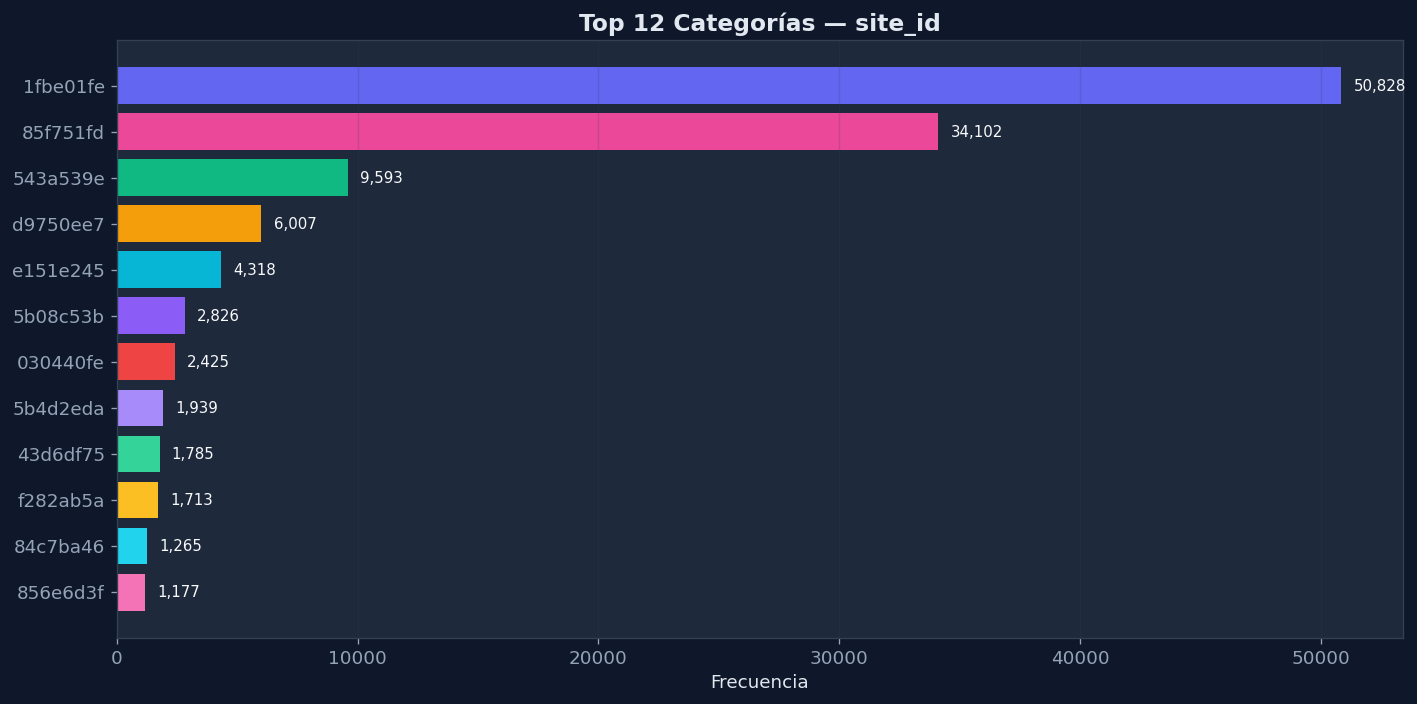

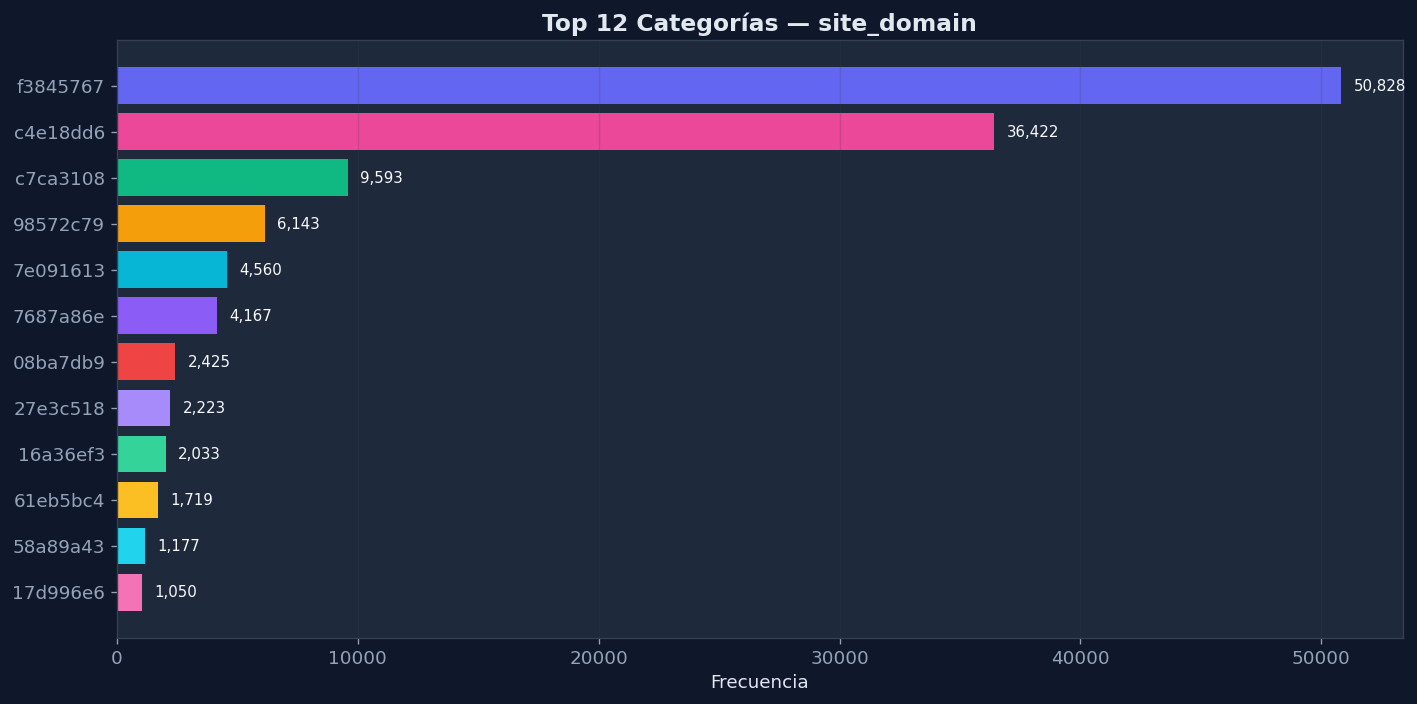

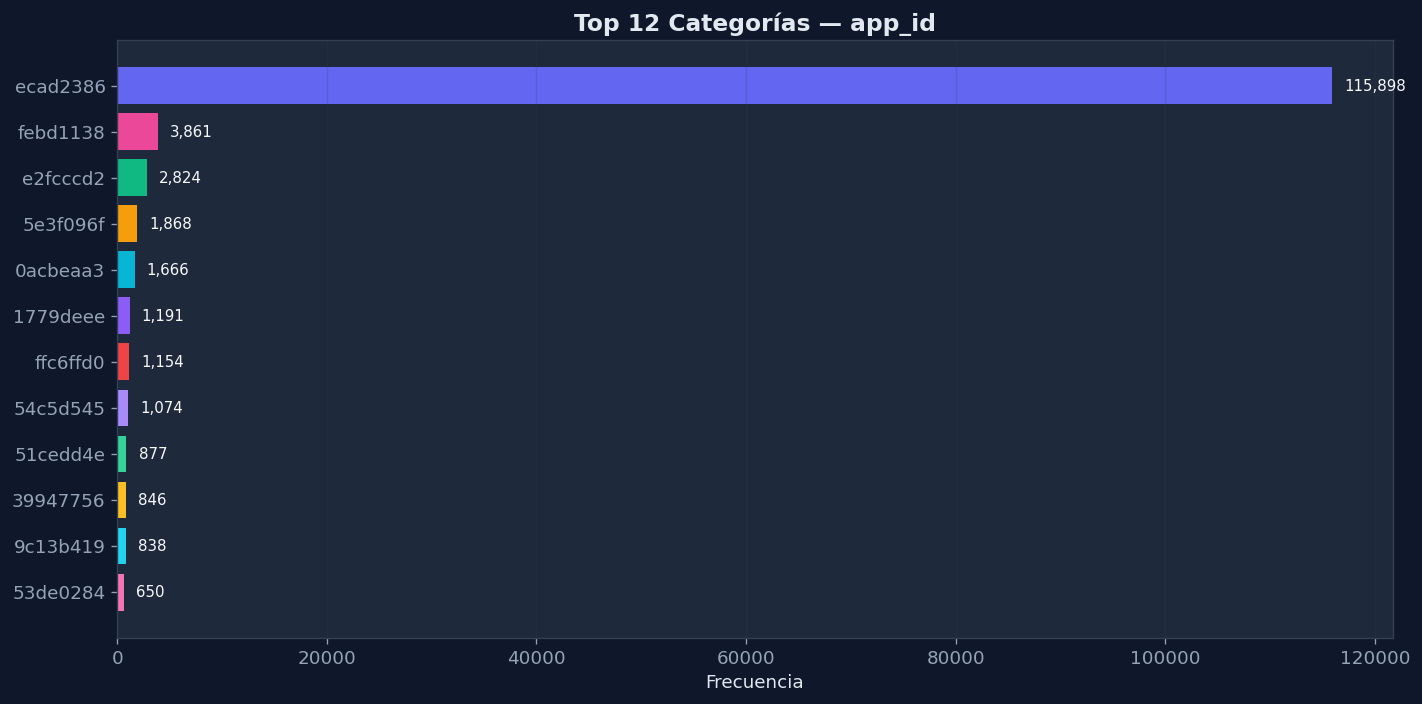

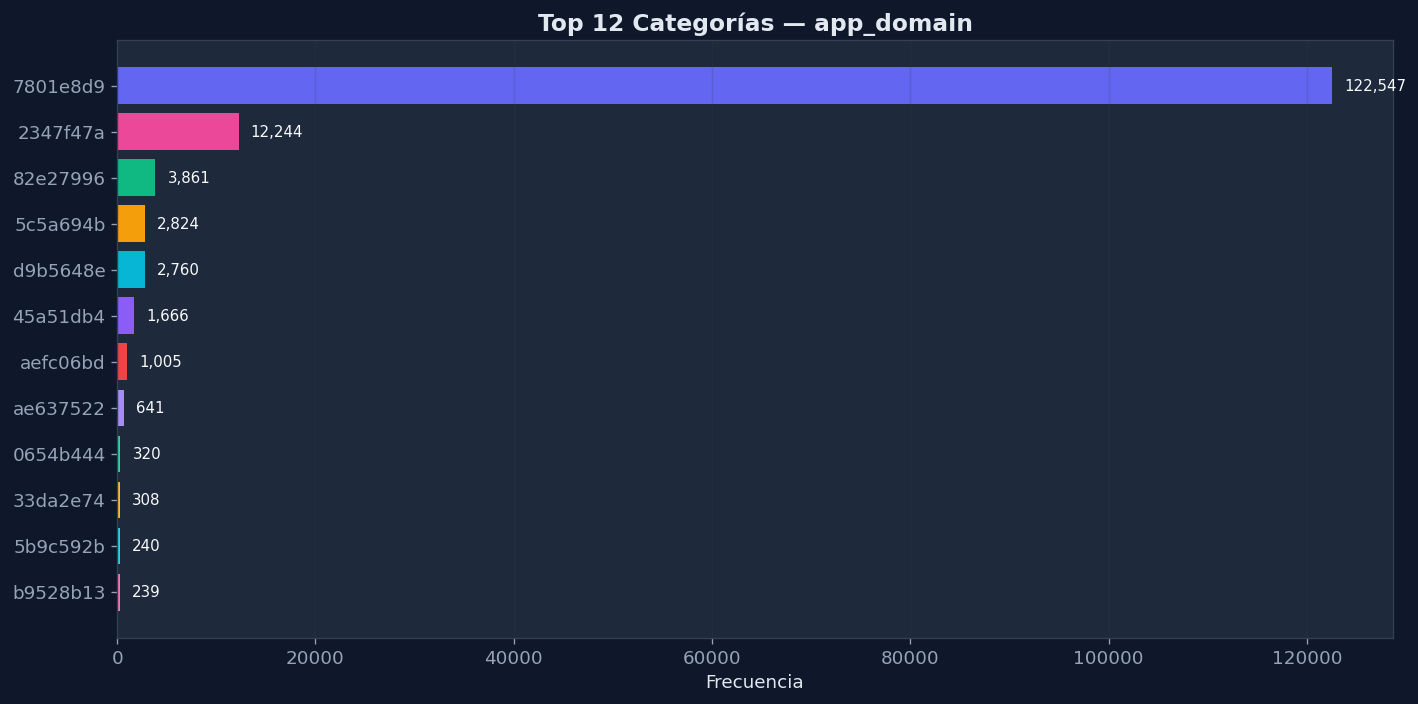

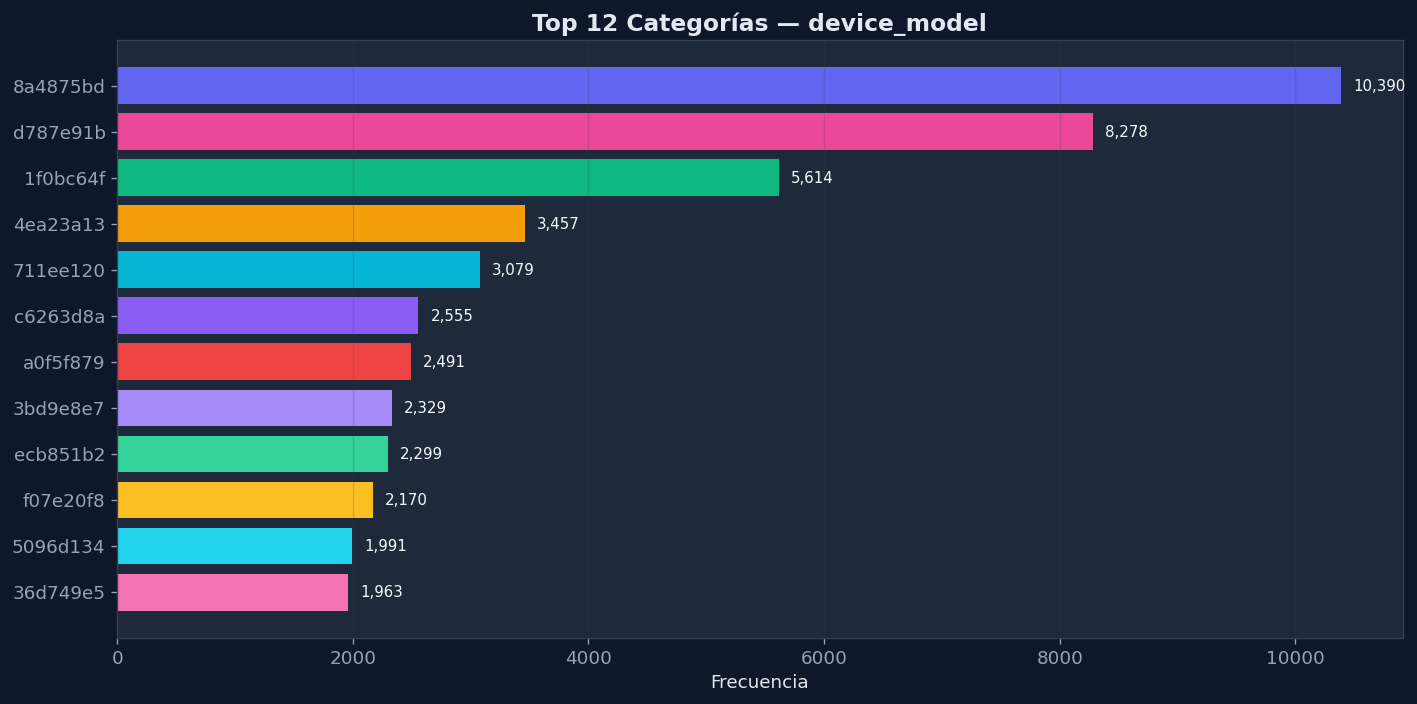

In [9]:
cat_vars = ["site_id", "site_domain", "app_id", "app_domain", "device_model"]
for col in cat_vars:
    fig = plot_top_categories(
        preview_df, col, top_n=12,
        save_path=FIGURES_DIR / f"01_top_categories_{col}.png"
    )
    plt.show()

---

## 📉 2.3 Distribución de Clics por Hora del Día

> **El CTR varía significativamente a lo largo del día. Las horas nocturnas y de madrugada suelen tener CTR diferentes a las horas laborales, reflejando distintos patrones de uso de dispositivos móviles.**

---

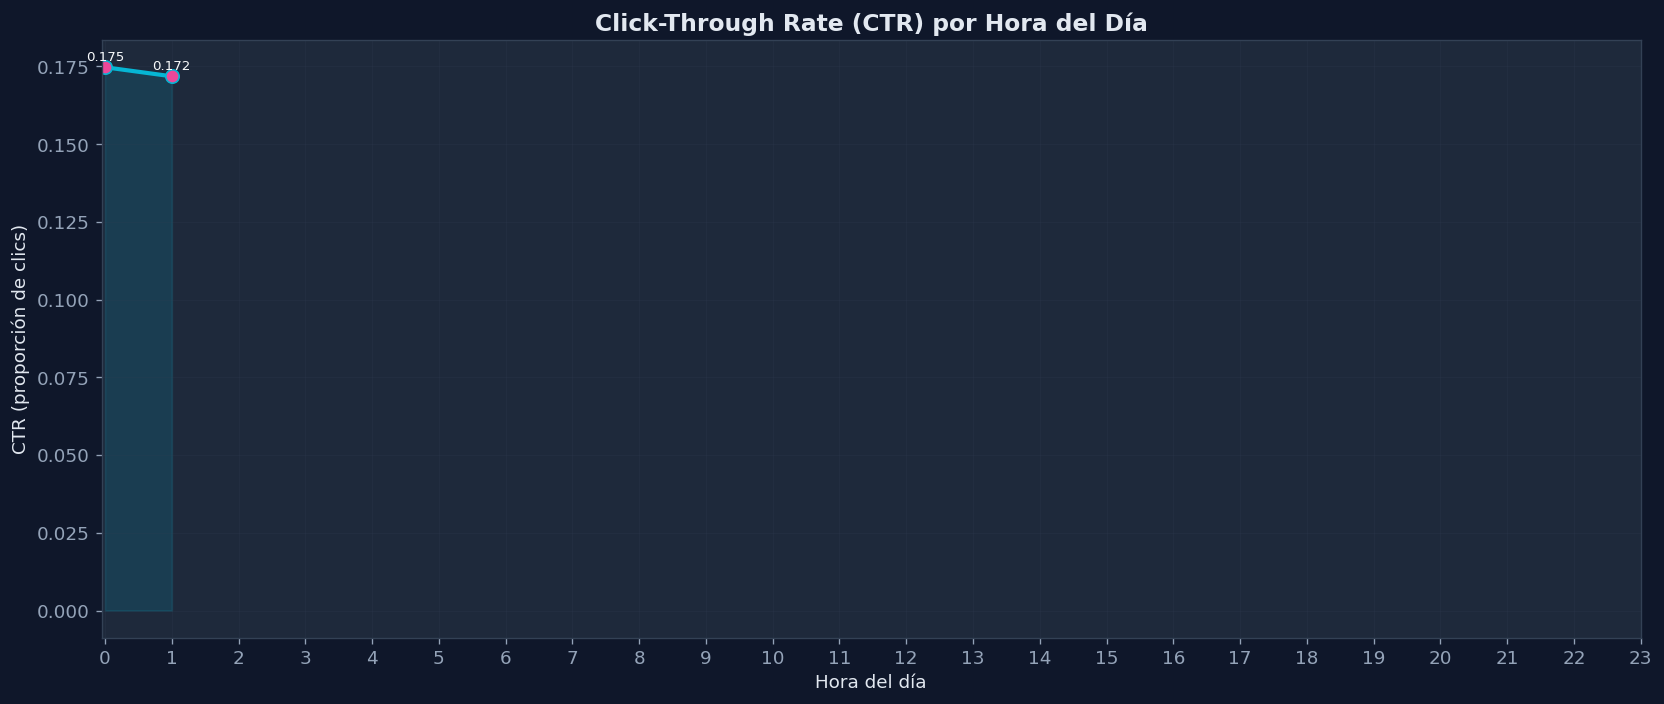

In [10]:
fig_ctr_hour = plot_click_rate_by_hour(
    preview_df, hour_col="event_hour", target_col=TARGET_COL,
    save_path=FIGURES_DIR / "01_ctr_by_hour.png"
)
plt.show()

---

## 🧩 2.4 Matriz de Correlación para Variables Numéricas

> **La matriz de correlación nos permite detectar multicolinealidad entre las features numéricas creadas. Variables altamente correlacionadas podrían aportar información redundante al modelo.**

---

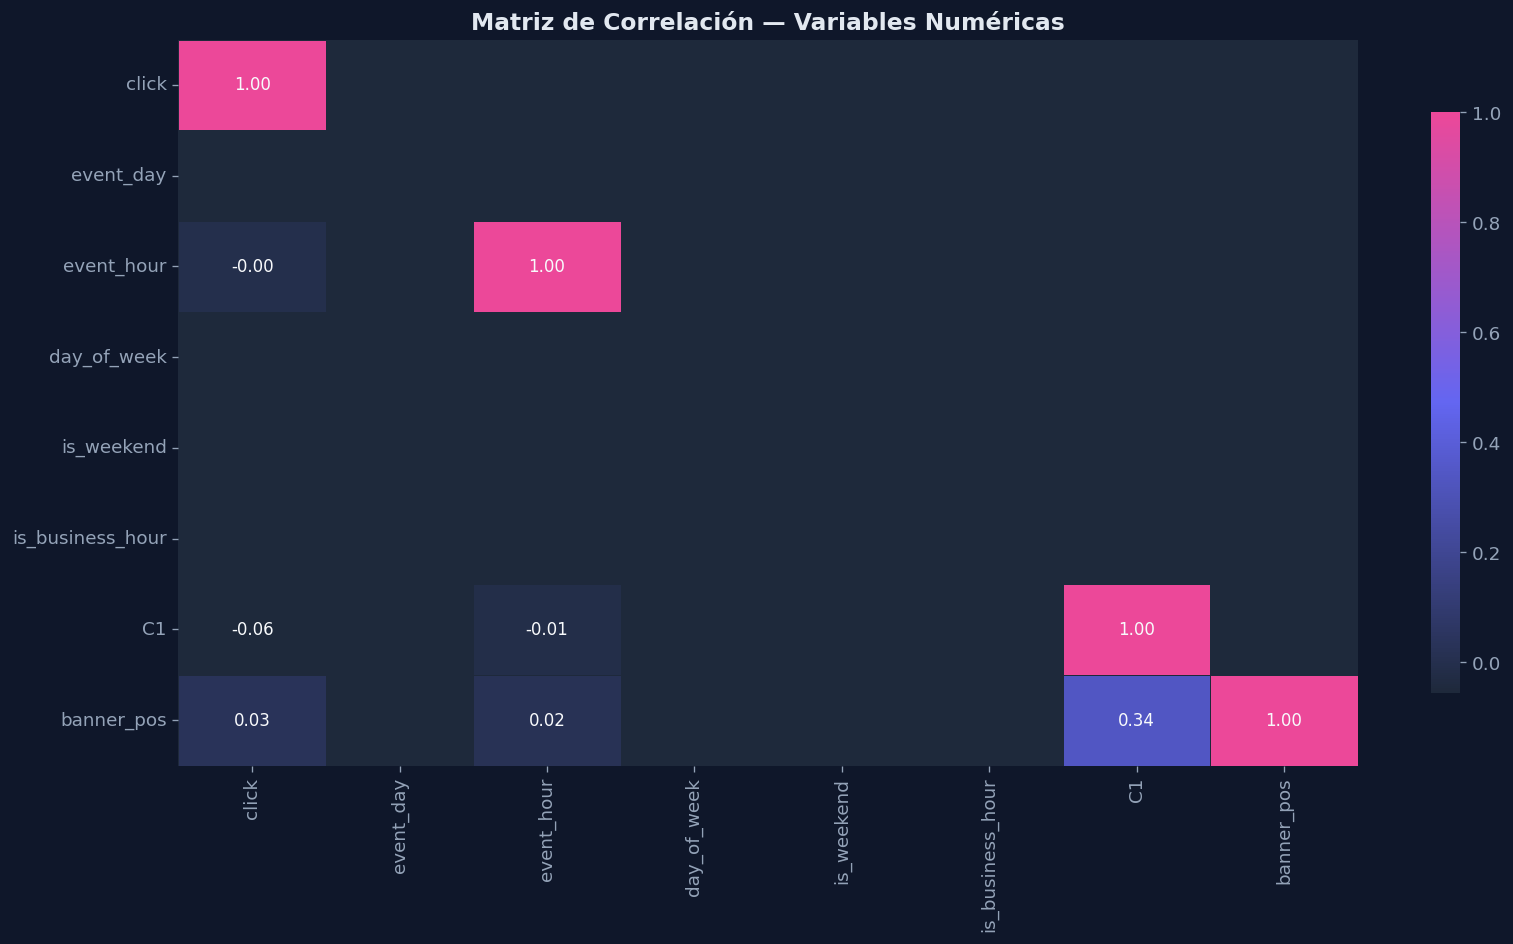

In [11]:
corr_cols = ["click", "event_day", "event_hour", "day_of_week",
             "is_weekend", "is_business_hour", "C1", "banner_pos"]
fig_corr = plot_correlation_heatmap(
    preview_df, corr_cols,
    save_path=FIGURES_DIR / "01_correlation_heatmap.png"
)
plt.show()

---

## 🌙 2.5 CTR por Franja Horaria

> **Agrupamos las horas en franjas (madrugada, mañana, tarde, noche) para ver patrones más amplios en el comportamiento de clics. Esta variable se usa como feature en el modelado.**

---

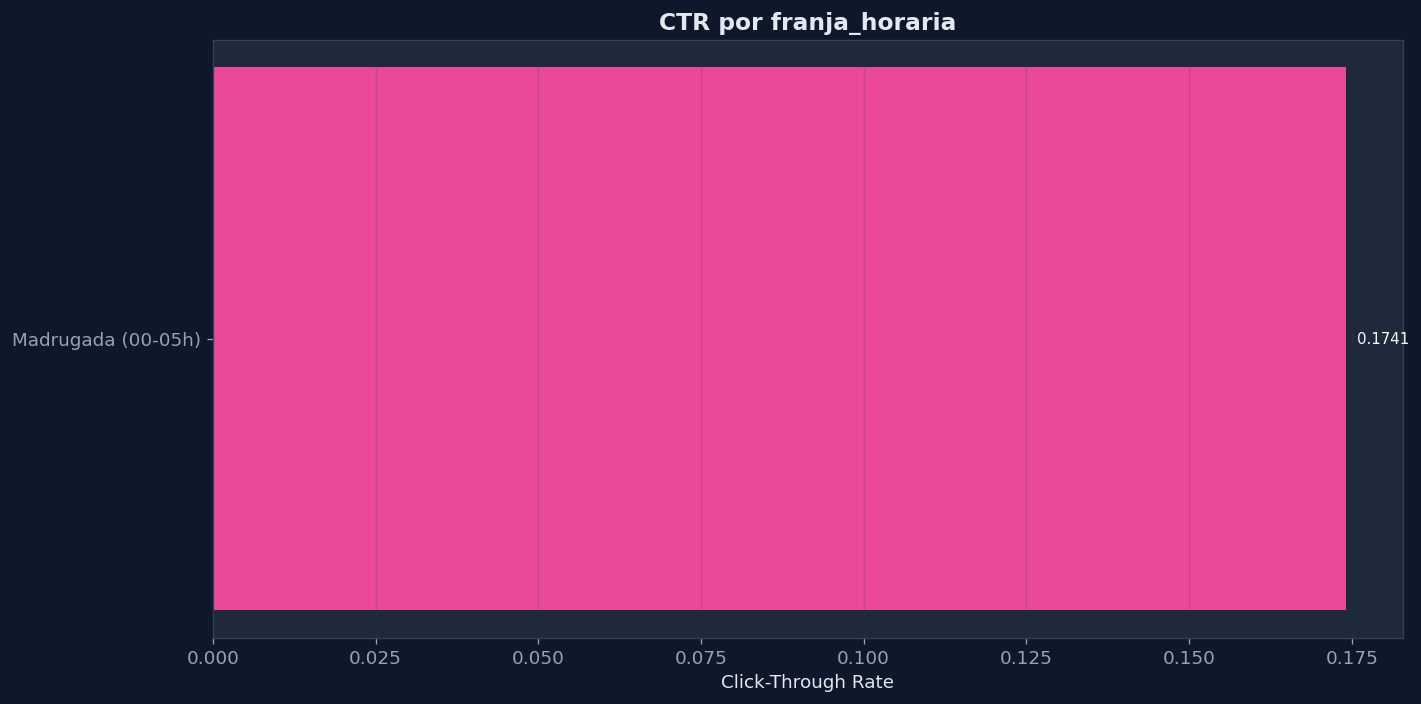

In [12]:
fig_franja = plot_ctr_by_category(
    preview_df, "franja_horaria", target_col=TARGET_COL,
    save_path=FIGURES_DIR / "01_ctr_by_franja_horaria.png"
)
plt.show()

---

## 📱 2.6 CTR por Tipo de Dispositivo (`device_type`)

> **Diferentes tipos de dispositivos pueden tener tasas de clic muy distintas. Los dispositivos móviles suelen tener pantallas más pequeñas donde los anuncios ocupan proporcionalmente más espacio visual.**

---

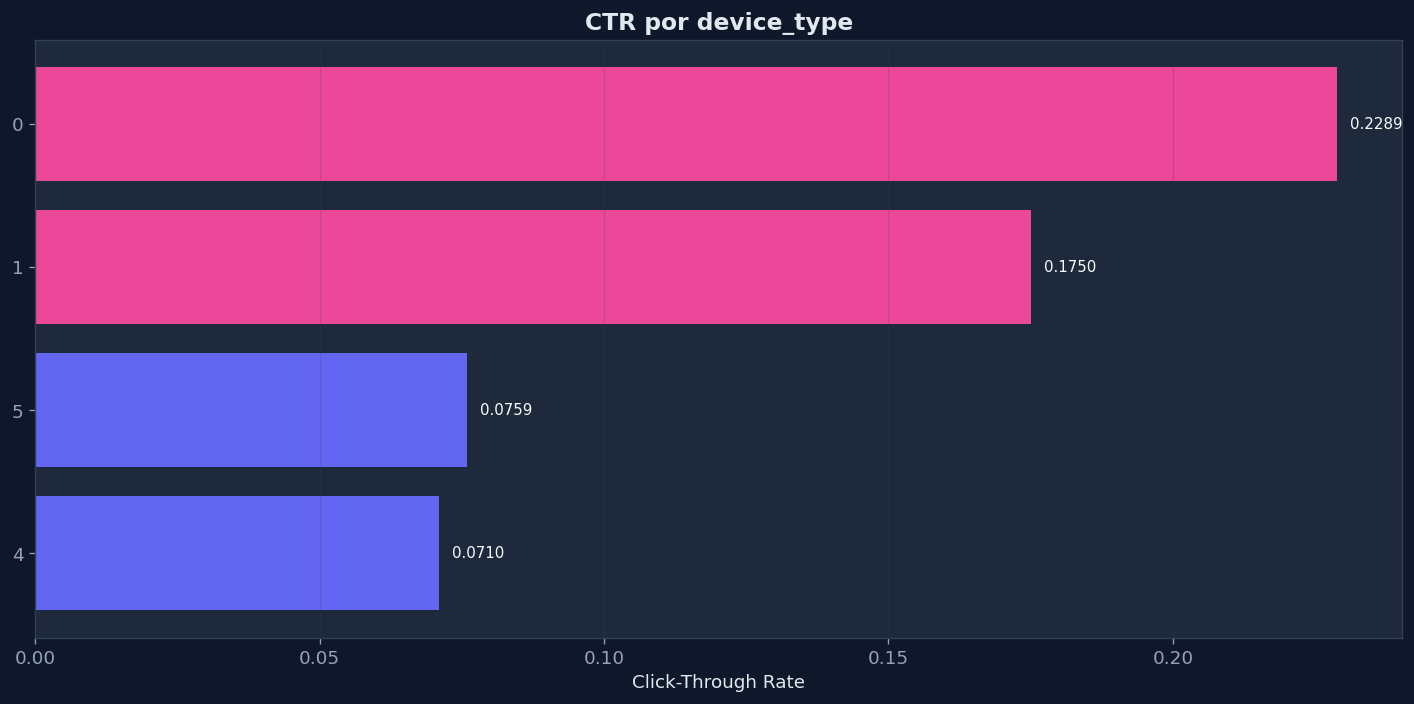

In [13]:
fig_device = plot_ctr_by_category(
    preview_df, "device_type", target_col=TARGET_COL,
    save_path=FIGURES_DIR / "01_ctr_by_device_type.png"
)
plt.show()

---

## 🖼️ 2.7 CTR por Posición del Banner (`banner_pos`)

> **La posición del anuncio en la pantalla es un factor clave en publicidad digital. Las posiciones más visibles (arriba de la página, por ejemplo) tienden a generar más clics.**

---

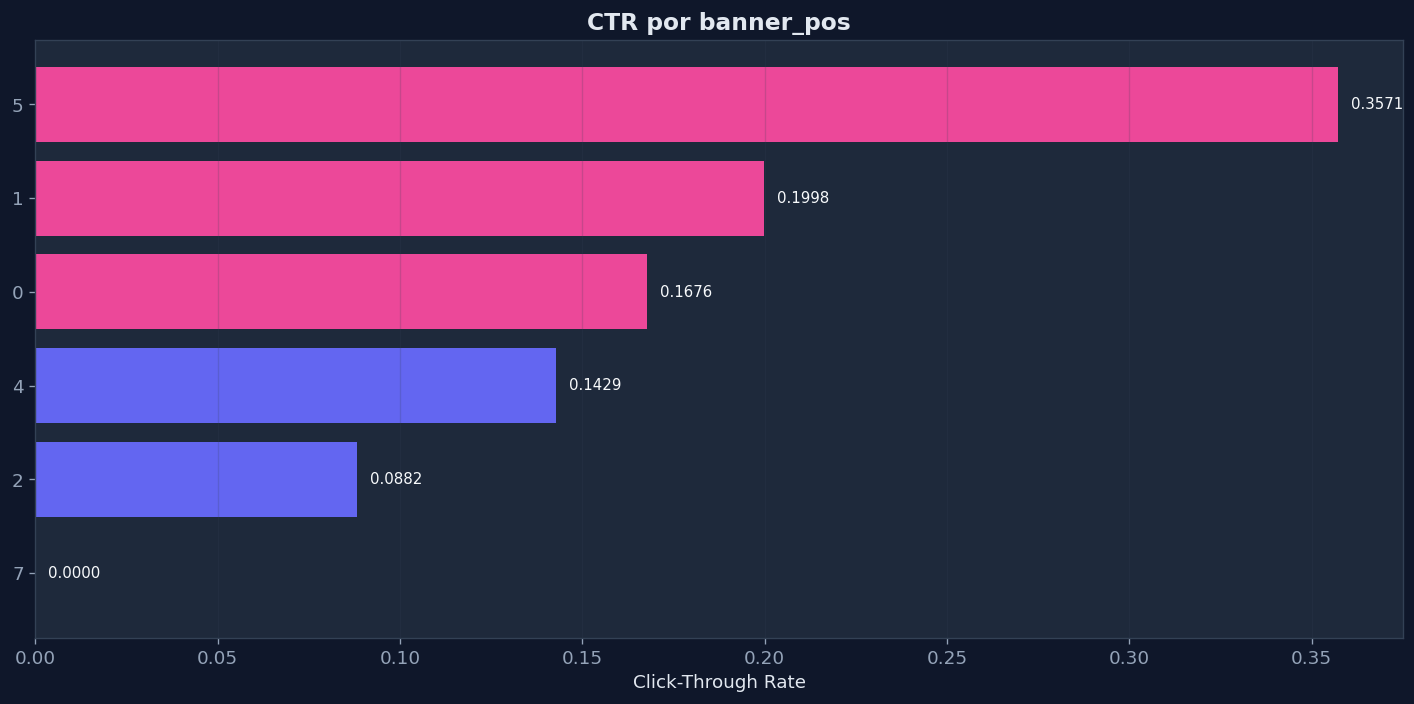

In [14]:
fig_banner = plot_ctr_by_category(
    preview_df, "banner_pos", target_col=TARGET_COL,
    save_path=FIGURES_DIR / "01_ctr_by_banner_pos.png"
)
plt.show()

---

## 🔗 2.8 CTR por Tipo de Conexión (`device_conn_type`)

> **El tipo de conexión (WiFi, 3G, 4G, etc.) puede influir en el comportamiento del usuario. Conexiones más rápidas pueden favorecer la interacción con anuncios rich media.**

---

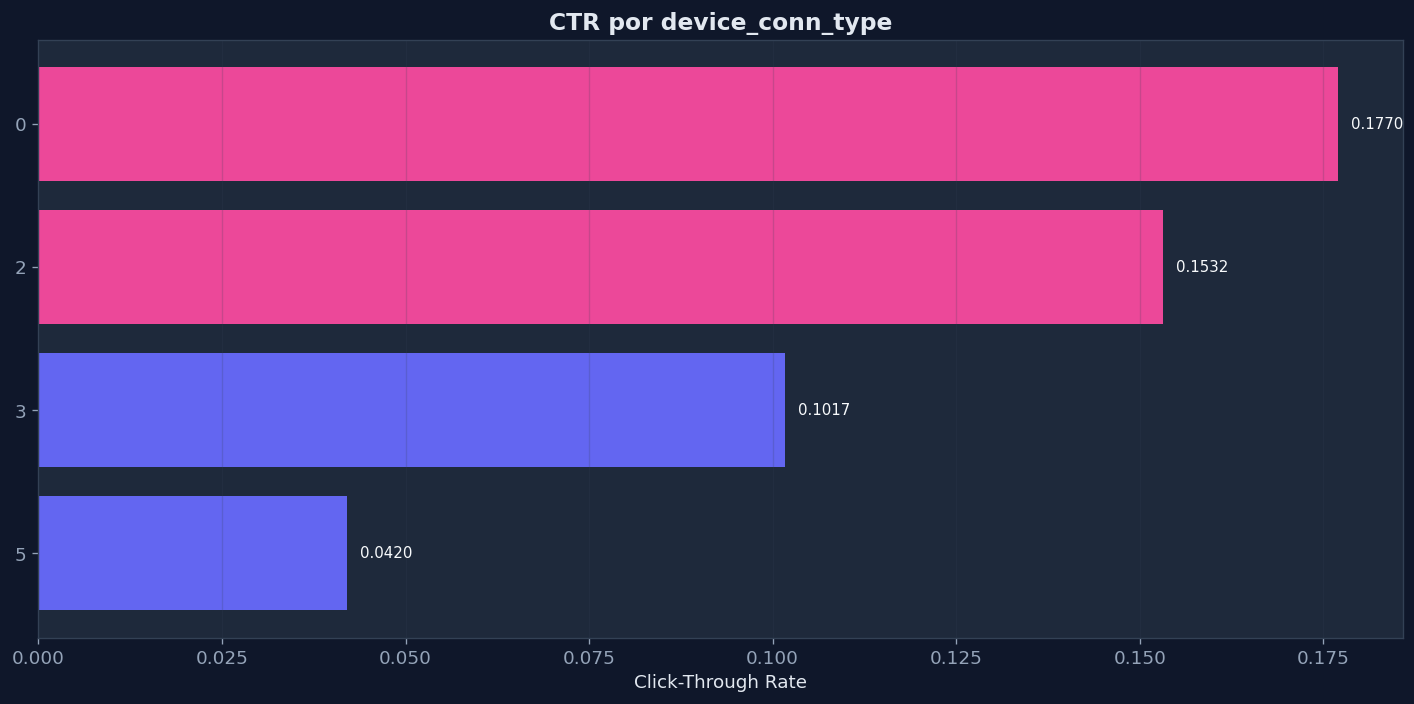

In [15]:
fig_conn = plot_ctr_by_category(
    preview_df, "device_conn_type", target_col=TARGET_COL,
    save_path=FIGURES_DIR / "01_ctr_by_device_conn_type.png"
)
plt.show()

---

## 🌐 2.9 Top 10 `site_id` por Volumen y su CTR

> **Identificamos los sitios web con mayor volumen de impresiones y analizamos si los sitios más populares tienen tasas de clic proporcionalmente diferentes. Esto puede revelar nichos de alto engagement.**

---

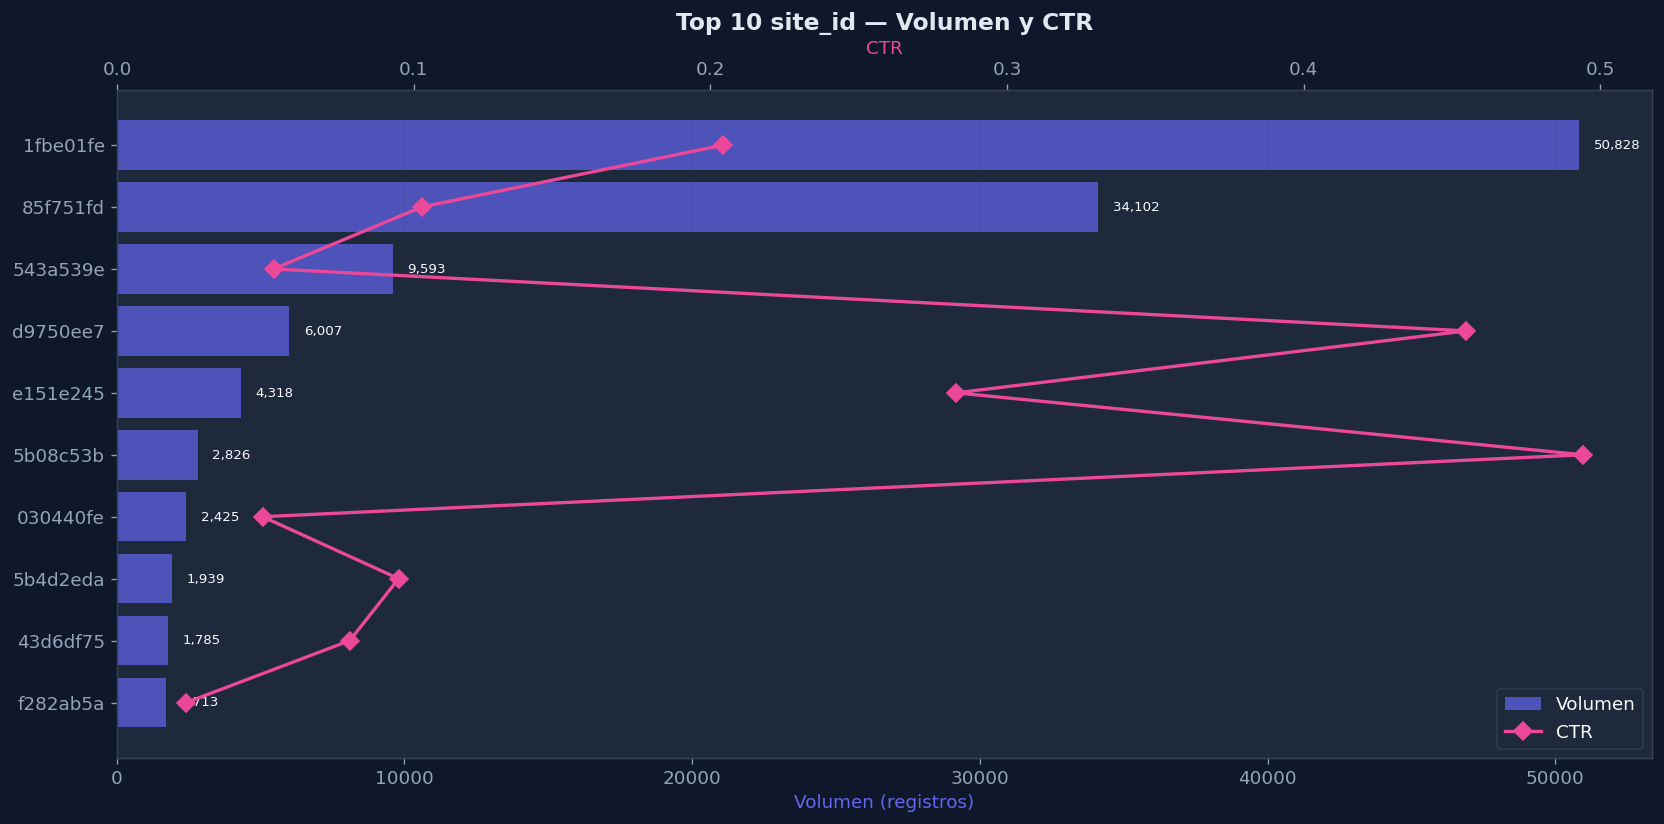

In [16]:
fig_site = plot_top_with_ctr(
    preview_df, "site_id", target_col=TARGET_COL, top_n=10,
    save_path=FIGURES_DIR / "01_top10_site_id_ctr.png"
)
plt.show()

---

## 📲 2.10 Top 10 `app_id` por Volumen y su CTR

> **De forma similar a los sitios web, analizamos las aplicaciones móviles con mayor volumen de impresiones. Las apps de ciertos verticales (juegos, noticias) suelen tener CTR característicos.**

---

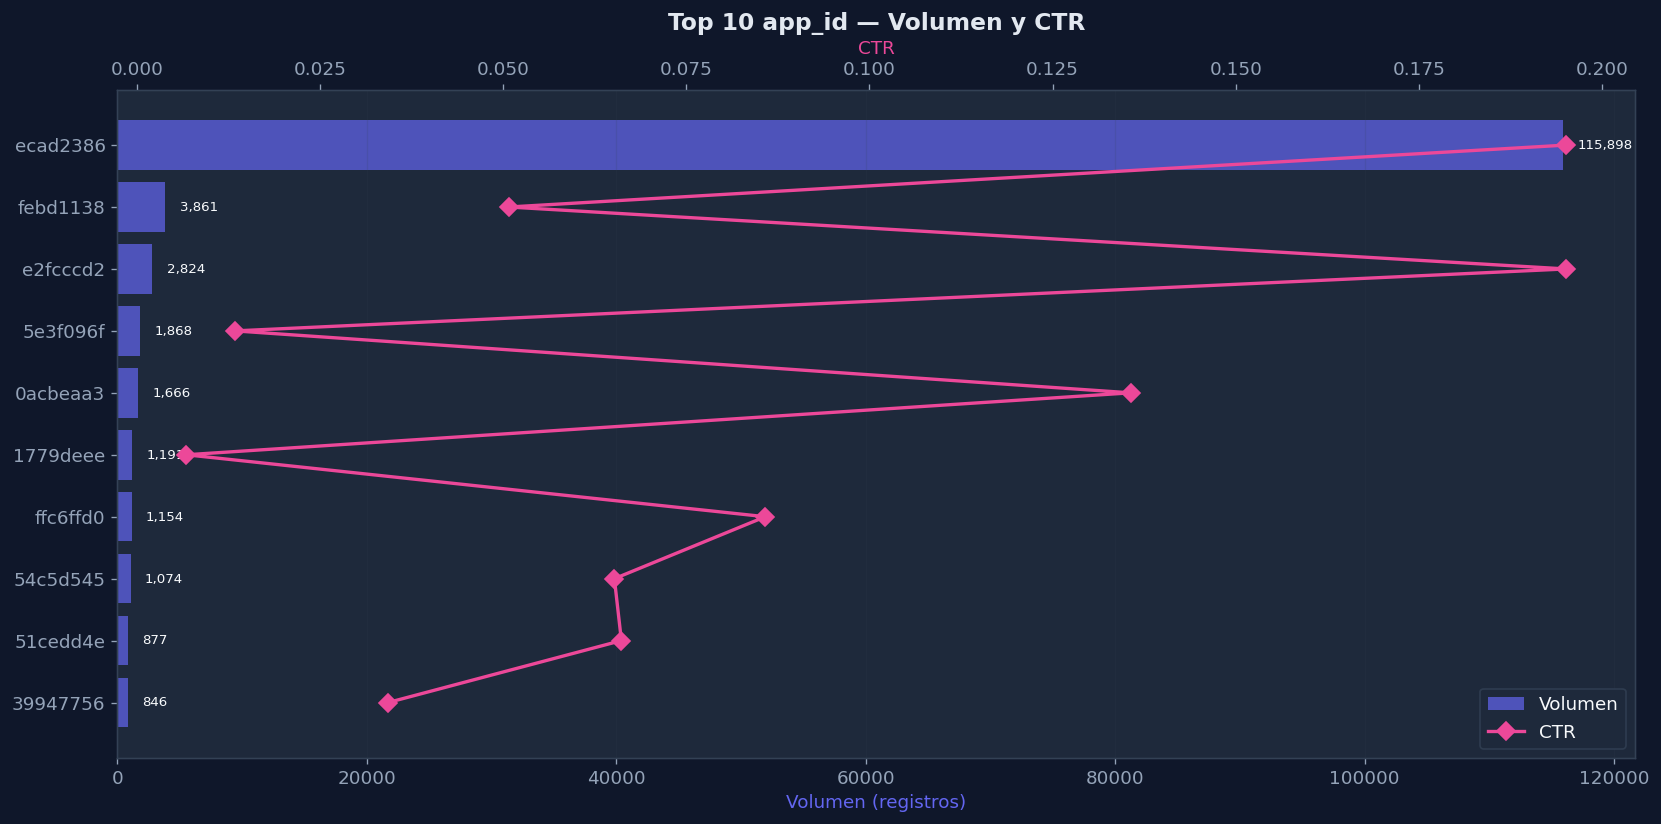

In [17]:
fig_app = plot_top_with_ctr(
    preview_df, "app_id", target_col=TARGET_COL, top_n=10,
    save_path=FIGURES_DIR / "01_top10_app_id_ctr.png"
)
plt.show()

---

## 📅 2.11 Distribución de Registros por Día

> **Analizamos cómo se distribuyen las impresiones a lo largo de los días disponibles en el dataset. Variaciones significativas pueden indicar eventos especiales, problemas de recolección o patrones estacionales.**

---

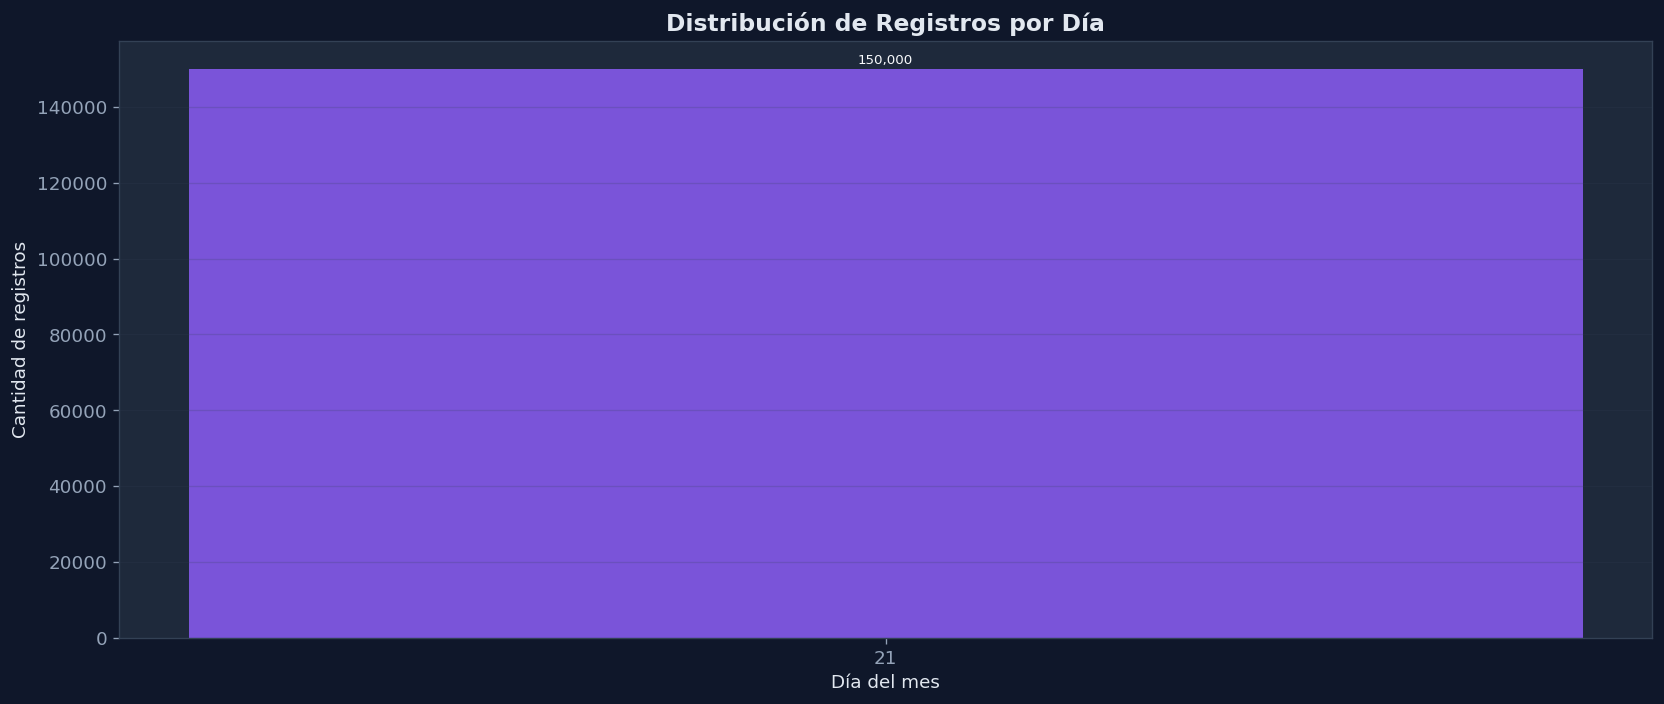

In [18]:
fig_day = plot_records_by_day(
    preview_df, day_col="event_day",
    save_path=FIGURES_DIR / "01_records_by_day.png"
)
plt.show()

---

## 🏆 2.12 Dashboard Resumen del Dataset

> **Consolidamos las métricas clave del dataset en un resumen visual tipo dashboard: total de registros, CTR global, número de features, variables categóricas, numéricas y valores faltantes.**

---

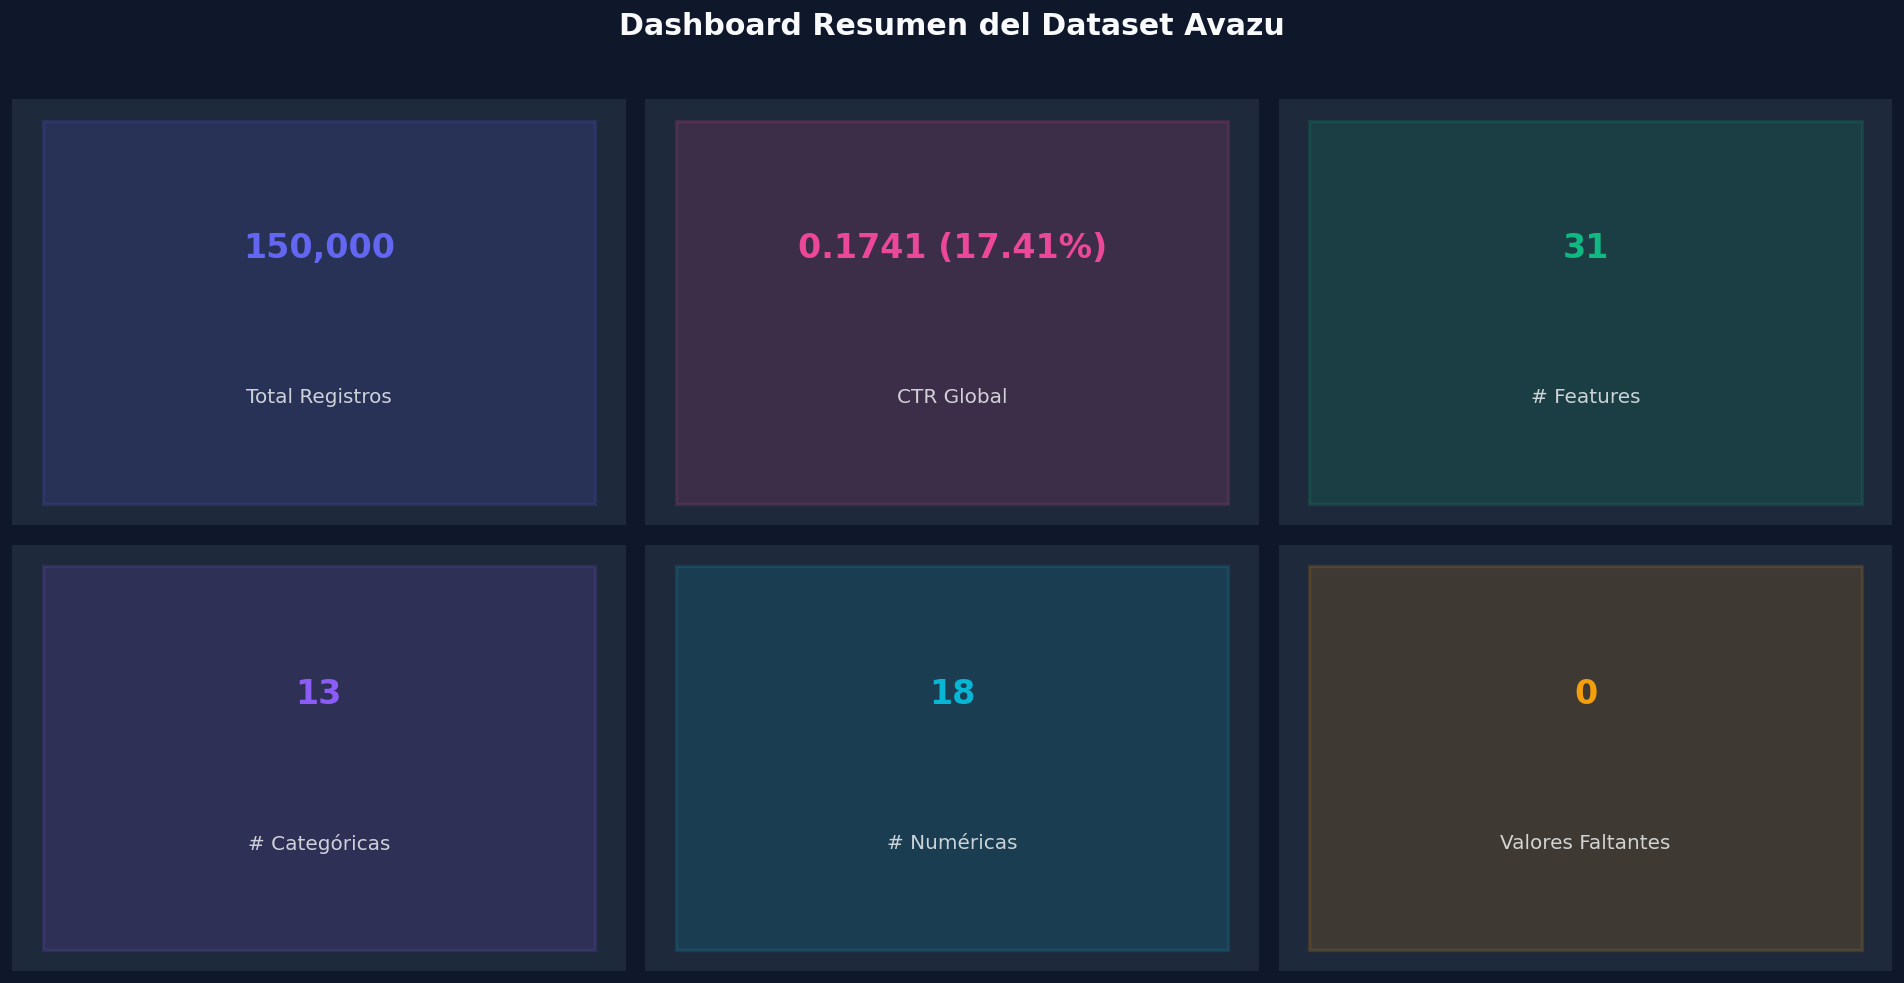

In [19]:
fig_dashboard = plot_dashboard_summary(
    preview_df, target_col=TARGET_COL,
    save_path=FIGURES_DIR / "01_dashboard_summary.png"
)
plt.show()

---

## 💡 3. Conclusiones del EDA

> **Resumen de los hallazgos más importantes del análisis exploratorio.**

### Hallazgos principales:

1. **Desbalance de clases**: El dataset presenta un fuerte desbalance típico de publicidad digital, con un CTR global cercano al 17%. Aunque es más alto que el estándar de la industria (2-5%), sigue siendo un dataset desbalanceado que requiere atención en el modelado.

2. **Alta cardinalidad**: Variables como `device_id`, `device_ip`, `site_id` y `app_id` tienen cardinalidades extremadamente altas (miles o millones de valores únicos). Estas variables requieren **Target Encoding** en lugar de OneHot para evitar explosión dimensional.

3. **Sin valores faltantes**: El dataset proviene de logs de servidores de publicidad y está completo, lo que simplifica el preprocesamiento.

4. **Patrones temporales**: El CTR varía significativamente por hora del día y franja horaria, lo que justifica la inclusión de features temporales en el modelo.

5. **Efecto de posición**: La posición del banner (`banner_pos`) muestra diferencias claras en CTR, confirmando que la ubicación del anuncio es un predictor importante.

6. **Concentración de tráfico**: Un pequeño número de `site_id` y `app_id` concentra la mayoría del volumen, con CTR variable entre ellos.

### Implicaciones para el modelado:
- Usar **muestreo estratificado** para mantener la proporción de clases.
- Aplicar **Target Encoding** para variables de alta cardinalidad.
- Incluir **features temporales** (hora, día, franja) como predictores.
- Excluir `id`, `device_id` y `device_ip` por alta cardinalidad sin valor predictivo.

---